In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import subprocess
import sys

REPO_URL = "https://github.com/bahaa1515/EECE-693-project.git"
COLAB_REPO_DIR = Path("/content/EECE-693-project")

def find_project_root() -> Path:
    for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (candidate / "src" / "config.py").exists():
            return candidate
    if COLAB_REPO_DIR.exists() and (COLAB_REPO_DIR / "src" / "config.py").exists():
        return COLAB_REPO_DIR
    try:
        import google.colab  # type: ignore  # noqa: F401
    except ImportError as exc:
        raise FileNotFoundError(
            "Could not find the project root. Run this notebook from the repo root, "
            "from the notebooks folder, or clone the repo in Colab first."
        ) from exc
    subprocess.run(["git", "clone", REPO_URL, str(COLAB_REPO_DIR)], check=True)
    return COLAB_REPO_DIR

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f"Project root: {PROJECT_ROOT}")

from src.config import DATA_RAW, DATA_PROCESSED, OUTPUT_TABLES


In [2]:
features_path = DATA_PROCESSED / "baseline_smartwatch_features.parquet"
weekly_path = DATA_RAW / "anonym_aamos00_weeklyquestionnaire.csv"

features_df = pd.read_parquet(features_path)
weekly_df = pd.read_csv(weekly_path)

print("Features shape:", features_df.shape)
print("Weekly questionnaire shape:", weekly_df.shape)

print("\nFeature columns:")
print(features_df.columns.tolist())

print("\nWeekly columns:")
print(weekly_df.columns.tolist())

weekly_df.head()

Features shape: (33812, 36)
Weekly questionnaire shape: (324, 12)

Feature columns:
['user_key', 'anchor_relative_minute', 'window_start_minute', 'window_end_minute', 'observed_minutes', 'coverage', 'n_rows_in_window', 'hr_mean', 'hr_std', 'hr_min', 'hr_max', 'hr_median', 'hr_missing_pct', 'steps_sum', 'steps_mean', 'steps_max', 'intensity_mean', 'intensity_std', 'intensity_max', 'active_minute_frac', 'activity_frac_walk', 'activity_frac_running', 'activity_frac_activity_high', 'activity_frac_sedentary', 'activity_frac_sleep', 'activity_frac_not_worn', 'activity_frac_charging', 'activity_frac_unknown', 'day_hr_mean', 'night_hr_mean', 'day_steps_sum', 'night_steps_sum', 'day_active_frac', 'night_active_frac', 'hr_slope', 'steps_slope']

Weekly columns:
['user_key', 'date', 'weekly_night_symp', 'weekly_day_symp', 'weekly_limit_activity', 'weekly_short_breath', 'weekly_wheeze', 'weekly_relief_inhaler', 'weekly_doc', 'weekly_hospital', 'weekly_er', 'weekly_oral']


,user_key,date,weekly_night_symp,weekly_day_symp,weekly_limit_activity,weekly_short_breath,weekly_wheeze,weekly_relief_inhaler,weekly_doc,weekly_hospital,weekly_er,weekly_oral
0,113,1,2.0,3.0,1.0,2,2,3,-4,0,0,2.0
1,113,7,2.0,3.0,2.0,2,2,2,-5,0,0,2.0
2,113,14,5.0,5.0,5.0,4,4,5,"-1,-3",0,-2,3.0
3,113,22,4.0,5.0,4.0,4,2,4,-3,0,0,3.0
4,113,28,3.0,3.0,3.0,3,2,3,0,0,0,3.0


In [13]:
weekly_missing = weekly_df.isna().mean().sort_values(ascending=False) * 100
print("Missing % per weekly column:")
display(weekly_missing)

for col in weekly_df.columns:
    print(f"\n--- {col} ---")
    print(weekly_df[col].value_counts(dropna=False).head(15))

Missing % per weekly column:


weekly_night_symp        54.320988
weekly_limit_activity    35.493827
weekly_day_symp          10.185185
weekly_doc                0.308642
weekly_oral               0.308642
date                      0.000000
user_key                  0.000000
weekly_short_breath       0.000000
weekly_relief_inhaler     0.000000
weekly_wheeze             0.000000
weekly_hospital           0.000000
weekly_er                 0.000000
dtype: float64


--- user_key ---
user_key
113    27
294    27
343    27
702    26
190    25
939    25
701    24
473    23
514    23
867    18
447    16
808    16
625    12
764     9
398     6
Name: count, dtype: int64

--- date ---
date
7      16
0      15
14     14
35     13
21     12
28     10
42     10
49     10
84     10
63      8
77      8
91      8
56      7
119     7
70      6
Name: count, dtype: int64

--- weekly_night_symp ---
weekly_night_symp
NaN    176
1.0     53
2.0     32
3.0     27
4.0     17
7.0     10
5.0      5
6.0      3
1.2      1
Name: count, dtype: int64

--- weekly_day_symp ---
weekly_day_symp
7.0    155
NaN     33
5.0     29
2.0     27
1.0     22
6.0     22
3.0     21
4.0     15
Name: count, dtype: int64

--- weekly_limit_activity ---
weekly_limit_activity
NaN    115
7.0     50
2.0     37
1.0     36
3.0     34
5.0     24
4.0     16
6.0     12
Name: count, dtype: int64

--- weekly_short_breath ---
weekly_short_breath
2    177
3     62
4     40
1     37
5      8
Name: count, dty

In [3]:
USER_COL = "user_key"
WEEKLY_DAY_COL = "date"

weekly_cols_of_interest = [
    "weekly_night_symp",
    "weekly_day_symp",
    "weekly_limit_activity",
    "weekly_short_breath",
    "weekly_wheeze",
    "weekly_relief_inhaler",
    "weekly_doc",
    "weekly_hospital",
    "weekly_er",
    "weekly_oral"
]

In [4]:
weekly = weekly_df[[USER_COL, WEEKLY_DAY_COL] + weekly_cols_of_interest].copy()

weekly = weekly.dropna(subset=[USER_COL, WEEKLY_DAY_COL]).copy()
weekly = weekly.drop_duplicates().copy()

print("Clean weekly shape:", weekly.shape)
weekly.head()

Clean weekly shape: (324, 12)


,user_key,date,weekly_night_symp,weekly_day_symp,weekly_limit_activity,weekly_short_breath,weekly_wheeze,weekly_relief_inhaler,weekly_doc,weekly_hospital,weekly_er,weekly_oral
0,113,1,2.0,3.0,1.0,2,2,3,-4,0,0,2.0
1,113,7,2.0,3.0,2.0,2,2,2,-5,0,0,2.0
2,113,14,5.0,5.0,5.0,4,4,5,"-1,-3",0,-2,3.0
3,113,22,4.0,5.0,4.0,4,2,4,-3,0,0,3.0
4,113,28,3.0,3.0,3.0,3,2,3,0,0,0,3.0


In [5]:
# Convert numeric-looking columns safely
numeric_cols = [
    "weekly_night_symp",
    "weekly_day_symp",
    "weekly_limit_activity",
    "weekly_short_breath",
    "weekly_wheeze",
    "weekly_relief_inhaler",
    "weekly_hospital",
    "weekly_er",
    "weekly_oral"
]

for col in numeric_cols:
    weekly[col] = pd.to_numeric(weekly[col], errors="coerce")

# weekly_doc seems string-like in your file, so keep it as cleaned string
weekly["weekly_doc"] = weekly["weekly_doc"].fillna("0").astype(str).str.strip()

weekly.head()

,user_key,date,weekly_night_symp,weekly_day_symp,weekly_limit_activity,weekly_short_breath,weekly_wheeze,weekly_relief_inhaler,weekly_doc,weekly_hospital,weekly_er,weekly_oral
0,113,1,2.0,3.0,1.0,2,2,3,-4,0,0,2.0
1,113,7,2.0,3.0,2.0,2,2,2,-5,0,0,2.0
2,113,14,5.0,5.0,5.0,4,4,5,"-1,-3",0,-2,3.0
3,113,22,4.0,5.0,4.0,4,2,4,-3,0,0,3.0
4,113,28,3.0,3.0,3.0,3,2,3,0,0,0,3.0


In [6]:
weekly["doc_flag"] = weekly["weekly_doc"].ne("0")

weekly["hospital_flag"] = weekly["weekly_hospital"].fillna(0).gt(0)
weekly["er_flag"] = weekly["weekly_er"].fillna(0).gt(0)

weekly["oral_flag"] = weekly["weekly_oral"].fillna(0).ge(3)

weekly["symptom_flag"] = (
    weekly["weekly_short_breath"].fillna(0).ge(4) |
    weekly["weekly_wheeze"].fillna(0).ge(4) |
    weekly["weekly_relief_inhaler"].fillna(0).ge(4) |
    weekly["weekly_day_symp"].fillna(0).ge(4) |
    weekly["weekly_night_symp"].fillna(0).ge(3) |
    weekly["weekly_limit_activity"].fillna(0).ge(3)
)

In [7]:
# ── STEP 1: Audit individual flag contributions ──────────────────────────
# Which flags are driving the positive rate?

flag_cols = ["doc_flag", "hospital_flag", "er_flag", "oral_flag", "symptom_flag"]

print("=" * 60)
print("INDIVIDUAL FLAG AUDIT")
print("=" * 60)
for flag in flag_cols:
    n_true = weekly[flag].sum()
    pct = n_true / len(weekly) * 100
    print(f"  {flag:25s}: {int(n_true):5d} / {len(weekly)}  ({pct:.1f}%)")

print()
print("Combined target_binary (OR of all flags):")
combined = (
    weekly["doc_flag"] | weekly["hospital_flag"] | weekly["er_flag"] |
    weekly["oral_flag"] | weekly["symptom_flag"]
).astype(int)
print(f"  Positive:  {combined.sum()} / {len(combined)}  ({combined.mean()*100:.1f}%)")
print(f"  Negative:  {(combined == 0).sum()} / {len(combined)}  ({(1-combined.mean())*100:.1f}%)")

print()
print("── Flag co-occurrence matrix ──")
flag_df = weekly[flag_cols].astype(int)
print(flag_df.corr().round(2))

print()
print("── Symptom sub-flag breakdown ──")
symptom_sub = {
    "short_breath >= 4": weekly["weekly_short_breath"].fillna(0).ge(4).sum(),
    "wheeze >= 4":       weekly["weekly_wheeze"].fillna(0).ge(4).sum(),
    "relief_inhaler >= 4": weekly["weekly_relief_inhaler"].fillna(0).ge(4).sum(),
    "day_symp >= 4":     weekly["weekly_day_symp"].fillna(0).ge(4).sum(),
    "night_symp >= 3":   weekly["weekly_night_symp"].fillna(0).ge(3).sum(),
    "limit_activity >= 3": weekly["weekly_limit_activity"].fillna(0).ge(3).sum(),
}
for k, v in symptom_sub.items():
    print(f"  {k:25s}: {v:5d} / {len(weekly)}  ({v/len(weekly)*100:.1f}%)")

INDIVIDUAL FLAG AUDIT
  doc_flag                 :    43 / 324  (13.3%)
  hospital_flag            :     0 / 324  (0.0%)
  er_flag                  :     0 / 324  (0.0%)
  oral_flag                :    43 / 324  (13.3%)
  symptom_flag             :   238 / 324  (73.5%)

Combined target_binary (OR of all flags):
  Positive:  251 / 324  (77.5%)
  Negative:  73 / 324  (22.5%)

── Flag co-occurrence matrix ──
               doc_flag  hospital_flag  er_flag  oral_flag  symptom_flag
doc_flag           1.00            NaN      NaN       0.54          0.05
hospital_flag       NaN            NaN      NaN        NaN           NaN
er_flag             NaN            NaN      NaN        NaN           NaN
oral_flag          0.54            NaN      NaN       1.00          0.09
symptom_flag       0.05            NaN      NaN       0.09          1.00

── Symptom sub-flag breakdown ──
  short_breath >= 4        :    48 / 324  (14.8%)
  wheeze >= 4              :    18 / 324  (5.6%)
  relief_inhaler >= 

In [9]:
# ── STEP 2: Compare stricter labeling strategies ──────────────────────────
# The original thresholds yield ~77% positive — unrealistic for "exacerbation".
# Let's try two clinically tighter definitions and compare.

# Original target (for comparison only — uses the lenient thresholds from cell above)
original_symptom_flag = (
    weekly["weekly_short_breath"].fillna(0).ge(4) |
    weekly["weekly_wheeze"].fillna(0).ge(4) |
    weekly["weekly_relief_inhaler"].fillna(0).ge(4) |
    weekly["weekly_day_symp"].fillna(0).ge(4) |
    weekly["weekly_night_symp"].fillna(0).ge(3) |
    weekly["weekly_limit_activity"].fillna(0).ge(3)
)
target_original = (
    weekly["doc_flag"] | weekly["hospital_flag"] | weekly["er_flag"] |
    weekly["oral_flag"] | original_symptom_flag
).astype(int)

# Strategy A: Strict-clinical (only severe events)
#   hospital OR ER OR oral steroids >= 3 days  (ignore symptoms & routine doc)
target_strict = (
    weekly["hospital_flag"] |
    weekly["er_flag"] |
    weekly["oral_flag"]
).astype(int)

# Strategy B: Moderate (raised symptom thresholds + severe events)
symptom_flag_strict = (
    weekly["weekly_short_breath"].fillna(0).ge(5) |
    weekly["weekly_wheeze"].fillna(0).ge(5) |
    weekly["weekly_relief_inhaler"].fillna(0).ge(5) |
    weekly["weekly_day_symp"].fillna(0).ge(5) |
    weekly["weekly_night_symp"].fillna(0).ge(4) |
    weekly["weekly_limit_activity"].fillna(0).ge(4)
)
target_moderate = (
    weekly["hospital_flag"] |
    weekly["er_flag"] |
    weekly["oral_flag"] |
    symptom_flag_strict
).astype(int)

# Strategy C: keep doc_flag but tighten symptoms
target_with_doc = (
    weekly["doc_flag"] |
    weekly["hospital_flag"] |
    weekly["er_flag"] |
    weekly["oral_flag"] |
    symptom_flag_strict
).astype(int)

print("=" * 60)
print("LABELING STRATEGY COMPARISON")
print("=" * 60)
strategies = {
    "Original (lenient)":   target_original,
    "A: Strict-clinical":   target_strict,
    "B: Moderate":          target_moderate,
    "C: Moderate + doc":    target_with_doc,
}
for name, target in strategies.items():
    pos = target.sum()
    total = len(target)
    print(f"  {name:30s}: {pos:4d} / {total}  ({pos/total*100:.1f}% positive)")

print()
print("Choose the strategy that gives ~10-30% positive rate.")

LABELING STRATEGY COMPARISON
  Original (lenient)            :  251 / 324  (77.5% positive)
  A: Strict-clinical            :   43 / 324  (13.3% positive)
  B: Moderate                   :  224 / 324  (69.1% positive)
  C: Moderate + doc             :  234 / 324  (72.2% positive)

Choose the strategy that gives ~10-30% positive rate.


In [21]:
# ── DEEP DIAGNOSTIC: Symptom score distributions & threshold sweep ──────────
# Goal: Find the RIGHT positive rate — not so lenient it's 77%, not so strict it's 13%

print("=" * 70)
print("1. RAW SYMPTOM SCORE DISTRIBUTIONS (per questionnaire-week)")
print("=" * 70)

symptom_cols = [
    "weekly_day_symp", "weekly_night_symp", "weekly_short_breath",
    "weekly_wheeze", "weekly_relief_inhaler", "weekly_limit_activity"
]

for col in symptom_cols:
    vals = weekly[col].dropna()
    print(f"\n  {col}:")
    print(f"    mean={vals.mean():.2f}, median={vals.median():.1f}, "
          f"max={vals.max():.0f}, >0: {(vals>0).sum()}/{len(vals)} ({(vals>0).mean()*100:.1f}%)")
    vc = vals.value_counts().sort_index()
    for v, c in vc.items():
        bar = "█" * int(c / len(vals) * 50)
        print(f"    {int(v):2d}: {c:4d} ({c/len(vals)*100:5.1f}%) {bar}")

print("\n" + "=" * 70)
print("2. THRESHOLD SWEEP: symptom-based positive rate at questionnaire level")
print("=" * 70)
print(f"{'Threshold':>12s}  {'Pos':>5s}  {'Total':>5s}  {'Rate':>7s}  Description")
print("-" * 70)

# The key insight: day_symp alone at >=4 catches 68%. 
# We need to require MULTIPLE symptoms to be elevated simultaneously.
sweep_results = []

# Single-flag rates (for reference)
for thresh in range(3, 8):
    for col_short, col_full in [("day_symp", "weekly_day_symp"), 
                                  ("night_symp", "weekly_night_symp")]:
        flag = weekly[col_full].fillna(0).ge(thresh)
        n = flag.sum()
        sweep_results.append((f"{col_short}>={thresh}", n, len(flag), n/len(flag)*100))
        print(f"  {col_short}>={thresh:d}        {n:5d}  {len(flag):5d}  {n/len(flag)*100:6.1f}%")

print()
print("── COMPOSITE strategies at questionnaire level ──")

# Strategy D: require 2+ symptom domains elevated simultaneously
for min_domains in [2, 3, 4]:
    for thresh in [4, 5, 6]:
        domain_flags = pd.DataFrame({
            'day': weekly["weekly_day_symp"].fillna(0).ge(thresh),
            'night': weekly["weekly_night_symp"].fillna(0).ge(max(thresh-1, 3)),
            'breath': weekly["weekly_short_breath"].fillna(0).ge(thresh),
            'wheeze': weekly["weekly_wheeze"].fillna(0).ge(thresh),
            'relief': weekly["weekly_relief_inhaler"].fillna(0).ge(thresh),
            'limit': weekly["weekly_limit_activity"].fillna(0).ge(max(thresh-1, 3)),
        })
        n_domains = domain_flags.sum(axis=1)
        symptom_composite = n_domains.ge(min_domains)
        
        full_target = (
            weekly["doc_flag"] | weekly["hospital_flag"] | 
            weekly["er_flag"] | weekly["oral_flag"] | symptom_composite
        ).astype(int)
        
        n = full_target.sum()
        rate = n / len(full_target) * 100
        tag = f"≥{min_domains}domains≥{thresh}"
        print(f"  {tag:18s}   {n:5d}  {len(full_target):5d}  {rate:6.1f}%  "
              f"(clinical + ≥{min_domains} symptom domains ≥{thresh})")

print()
print("── Strategy E: Symptom severity SCORE (sum of all symptom cols) ──")
weekly["_symptom_total"] = (
    weekly["weekly_day_symp"].fillna(0) + 
    weekly["weekly_night_symp"].fillna(0) +
    weekly["weekly_short_breath"].fillna(0) +
    weekly["weekly_wheeze"].fillna(0) +
    weekly["weekly_relief_inhaler"].fillna(0) +
    weekly["weekly_limit_activity"].fillna(0)
)
print(f"  Symptom total score: mean={weekly['_symptom_total'].mean():.1f}, "
      f"median={weekly['_symptom_total'].median():.1f}, "
      f"p75={weekly['_symptom_total'].quantile(0.75):.1f}, "
      f"p90={weekly['_symptom_total'].quantile(0.90):.1f}, "
      f"max={weekly['_symptom_total'].max():.0f}")

for pct_thresh in [50, 60, 70, 75, 80, 85, 90]:
    cutoff = weekly["_symptom_total"].quantile(pct_thresh/100)
    symptom_severe = weekly["_symptom_total"].ge(cutoff)
    full_target = (
        weekly["doc_flag"] | weekly["hospital_flag"] | 
        weekly["er_flag"] | weekly["oral_flag"] | symptom_severe
    ).astype(int)
    n = full_target.sum()
    rate = n / len(full_target) * 100
    print(f"  p{pct_thresh} (cutoff={cutoff:5.1f})     {n:5d}  {len(full_target):5d}  {rate:6.1f}%")

# Clean up temp column
weekly.drop(columns=["_symptom_total"], inplace=True)

print()
print("="*70)
print("3. KEY QUESTION: How many UNIQUE USERS have positives under each?")
print("="*70)
print(f"  Strategy A (strict-clinical): "
      f"{weekly[weekly['doc_flag'] | weekly['hospital_flag'] | weekly['er_flag'] | weekly['oral_flag']][USER_COL].nunique()} users")
print(f"  Total users: {weekly[USER_COL].nunique()}")


1. RAW SYMPTOM SCORE DISTRIBUTIONS (per questionnaire-week)

  weekly_day_symp:
    mean=5.36, median=7.0, max=7, >0: 291/291 (100.0%)
     1:   22 (  7.6%) ███
     2:   27 (  9.3%) ████
     3:   21 (  7.2%) ███
     4:   15 (  5.2%) ██
     5:   29 ( 10.0%) ████
     6:   22 (  7.6%) ███
     7:  155 ( 53.3%) ██████████████████████████

  weekly_night_symp:
    mean=2.57, median=2.0, max=7, >0: 148/148 (100.0%)
     1:   53 ( 35.8%) █████████████████
     1:    1 (  0.7%) 
     2:   32 ( 21.6%) ██████████
     3:   27 ( 18.2%) █████████
     4:   17 ( 11.5%) █████
     5:    5 (  3.4%) █
     6:    3 (  2.0%) █
     7:   10 (  6.8%) ███

  weekly_short_breath:
    mean=2.40, median=2.0, max=5, >0: 324/324 (100.0%)
     1:   37 ( 11.4%) █████
     2:  177 ( 54.6%) ███████████████████████████
     3:   62 ( 19.1%) █████████
     4:   40 ( 12.3%) ██████
     5:    8 (  2.5%) █

  weekly_wheeze:
    mean=1.85, median=2.0, max=5, >0: 324/324 (100.0%)
     1:  127 ( 39.2%) ███████████████

In [22]:
# ── FOCUSED DIAGNOSTIC: Best composite strategies ──────────────────────
# Find the sweet spot between 77% (inflated) and 13% (too strict)

print("=" * 70)
print("STRATEGY COMPARISON — Final candidates")
print("=" * 70)

# Symptom total score for the percentile approach
_stot = (
    weekly["weekly_day_symp"].fillna(0) + weekly["weekly_night_symp"].fillna(0) +
    weekly["weekly_short_breath"].fillna(0) + weekly["weekly_wheeze"].fillna(0) +
    weekly["weekly_relief_inhaler"].fillna(0) + weekly["weekly_limit_activity"].fillna(0)
)
clinical_base = (weekly["doc_flag"] | weekly["hospital_flag"] | weekly["er_flag"] | weekly["oral_flag"])

candidates = {}

# A: strict clinical only
candidates["A: Clinical only"] = clinical_base.astype(int)

# D: clinical + ≥2 symptom domains ≥5
d2 = pd.DataFrame({
    'day': weekly["weekly_day_symp"].fillna(0).ge(5),
    'night': weekly["weekly_night_symp"].fillna(0).ge(4),
    'breath': weekly["weekly_short_breath"].fillna(0).ge(5),
    'wheeze': weekly["weekly_wheeze"].fillna(0).ge(5),
    'relief': weekly["weekly_relief_inhaler"].fillna(0).ge(5),
    'limit': weekly["weekly_limit_activity"].fillna(0).ge(4),
}).sum(axis=1).ge(2)
candidates["D: Clinical + 2domains≥5"] = (clinical_base | d2).astype(int)

# E: clinical + ≥3 symptom domains ≥4
d3 = pd.DataFrame({
    'day': weekly["weekly_day_symp"].fillna(0).ge(4),
    'night': weekly["weekly_night_symp"].fillna(0).ge(3),
    'breath': weekly["weekly_short_breath"].fillna(0).ge(4),
    'wheeze': weekly["weekly_wheeze"].fillna(0).ge(4),
    'relief': weekly["weekly_relief_inhaler"].fillna(0).ge(4),
    'limit': weekly["weekly_limit_activity"].fillna(0).ge(3),
}).sum(axis=1).ge(3)
candidates["E: Clinical + 3domains≥4"] = (clinical_base | d3).astype(int)

# F: clinical + symptom total ≥ p75
p75 = _stot.quantile(0.75)
candidates[f"F: Clinical + total≥p75({p75:.0f})"] = (clinical_base | _stot.ge(p75)).astype(int)

# G: clinical + symptom total ≥ p70
p70 = _stot.quantile(0.70)
candidates[f"G: Clinical + total≥p70({p70:.0f})"] = (clinical_base | _stot.ge(p70)).astype(int)

# H: clinical + ≥3 domains ≥5  (very strict symptoms)
d3_strict = pd.DataFrame({
    'day': weekly["weekly_day_symp"].fillna(0).ge(5),
    'night': weekly["weekly_night_symp"].fillna(0).ge(4),
    'breath': weekly["weekly_short_breath"].fillna(0).ge(5),
    'wheeze': weekly["weekly_wheeze"].fillna(0).ge(5),
    'relief': weekly["weekly_relief_inhaler"].fillna(0).ge(5),
    'limit': weekly["weekly_limit_activity"].fillna(0).ge(4),
}).sum(axis=1).ge(3)
candidates["H: Clinical + 3domains≥5"] = (clinical_base | d3_strict).astype(int)

# Original for reference
original_symp = (
    weekly["weekly_short_breath"].fillna(0).ge(4) |
    weekly["weekly_wheeze"].fillna(0).ge(4) |
    weekly["weekly_relief_inhaler"].fillna(0).ge(4) |
    weekly["weekly_day_symp"].fillna(0).ge(4) |
    weekly["weekly_night_symp"].fillna(0).ge(3) |
    weekly["weekly_limit_activity"].fillna(0).ge(3)
)
candidates["ORIG: Any 1 domain≥4"] = (clinical_base | original_symp).astype(int)

print(f"{'Strategy':40s} {'Pos':>5s} {'Total':>5s}  {'Rate':>7s}  {'#Users w/ pos':>13s}")
print("-" * 80)
for name, tgt in candidates.items():
    n = tgt.sum()
    total = len(tgt)
    rate = n / total * 100
    # How many unique users have at least 1 positive?
    users_pos = weekly.loc[tgt == 1, USER_COL].nunique()
    users_total = weekly[USER_COL].nunique()
    print(f"  {name:38s} {n:5d} {total:5d}  {rate:6.1f}%   {users_pos}/{users_total} users")

print()
print("TARGET: 20-35% positive rate with positives spread across users")
print("Sweet spot candidates are likely D, E, F, or H")


STRATEGY COMPARISON — Final candidates
Strategy                                   Pos Total     Rate  #Users w/ pos
--------------------------------------------------------------------------------
  A: Clinical only                          60   324    18.5%   10/22 users
  D: Clinical + 2domains≥5                 147   324    45.4%   15/22 users
  E: Clinical + 3domains≥4                  95   324    29.3%   14/22 users
  F: Clinical + total≥p75(19)              125   324    38.6%   16/22 users
  G: Clinical + total≥p70(18)              138   324    42.6%   16/22 users
  H: Clinical + 3domains≥5                  75   324    23.1%   12/22 users
  ORIG: Any 1 domain≥4                     251   324    77.5%   19/22 users

TARGET: 20-35% positive rate with positives spread across users
Sweet spot candidates are likely D, E, F, or H


In [23]:
# ── STEP 3: Apply the chosen labeling strategy ──────────────────────────
# Strategy E: Clinical events + ≥3 symptom domains simultaneously elevated
#
# Rationale:
# - Strategy A (clinical only) → 18.5%, but only 10/22 users had positives
#   → GroupKFold CV had near-random AUC due to folds with ~0 positives
# - Original (any 1 domain ≥ 4) → 77.5%, clinically unrealistic
# - Strategy E requires 3+ symptom domains elevated AT THE SAME TIME,
#   meaning the patient is having a genuinely "bad week" across breathing,
#   sleep, activity limitation, etc.  → 29.3%, 14/22 users covered.
#
# Clinical events: doc visit | hospital | ER | oral steroids ≥ 3 days
# Severe symptoms: ≥ 3 of {day_symp≥4, night_symp≥3, short_breath≥4,
#                           wheeze≥4, relief_inhaler≥4, limit_activity≥3}

# Composite symptom flag: 3+ domains elevated simultaneously
symptom_domains = pd.DataFrame({
    'day':    weekly["weekly_day_symp"].fillna(0).ge(4),
    'night':  weekly["weekly_night_symp"].fillna(0).ge(3),
    'breath': weekly["weekly_short_breath"].fillna(0).ge(4),
    'wheeze': weekly["weekly_wheeze"].fillna(0).ge(4),
    'relief': weekly["weekly_relief_inhaler"].fillna(0).ge(4),
    'limit':  weekly["weekly_limit_activity"].fillna(0).ge(3),
})
multi_symptom_flag = symptom_domains.sum(axis=1).ge(3)

weekly["target_binary"] = (
    weekly["doc_flag"] |
    weekly["hospital_flag"] |
    weekly["er_flag"] |
    weekly["oral_flag"] |
    multi_symptom_flag
).astype(int)

print("FINAL label distribution (Strategy E - Clinical + 3 symptom domains >= 4):")
print(weekly["target_binary"].value_counts(dropna=False))
print("\nNormalized:")
print(weekly["target_binary"].value_counts(normalize=True, dropna=False))
print(f"\nPositive rate: {weekly['target_binary'].mean()*100:.1f}%")
print(f"Users with >=1 positive: {weekly.loc[weekly['target_binary']==1, USER_COL].nunique()}/{weekly[USER_COL].nunique()}")

FINAL label distribution (Strategy E - Clinical + 3 symptom domains >= 4):
target_binary
0    229
1     95
Name: count, dtype: int64

Normalized:
target_binary
0    0.70679
1    0.29321
Name: proportion, dtype: float64

Positive rate: 29.3%
Users with >=1 positive: 14/22


In [24]:
weekly["week_end_day"] = pd.to_numeric(weekly[WEEKLY_DAY_COL], errors="coerce")

# Because questionnaire is filled the next morning / next day
weekly["questionnaire_day"] = weekly["week_end_day"] + 1

weekly["questionnaire_relative_minute"] = weekly["questionnaire_day"] * 1440

weekly[[USER_COL, WEEKLY_DAY_COL, "week_end_day", "questionnaire_day", "questionnaire_relative_minute", "target_binary"]].head()

,user_key,date,week_end_day,questionnaire_day,questionnaire_relative_minute,target_binary
0,113,1,1,2,2880,1
1,113,7,7,8,11520,1
2,113,14,14,15,21600,1
3,113,22,22,23,33120,1
4,113,28,28,29,41760,1


In [25]:
print("Feature timing check:")
print(features_df[[USER_COL, "anchor_relative_minute"]].head())

print("\nUsers in features:", features_df[USER_COL].nunique())
print("Users in weekly:", weekly[USER_COL].nunique())

Feature timing check:
   user_key  anchor_relative_minute
0       113                    2015
1       113                    2075
2       113                    2135
3       113                    2195
4       113                    2255

Users in features: 18
Users in weekly: 22


In [26]:
features_sorted = features_df.sort_values("anchor_relative_minute").copy()

weekly_sorted = weekly.sort_values("questionnaire_relative_minute").copy()

print(features_sorted.shape, weekly_sorted.shape)

(33812, 36) (324, 21)


In [27]:
print("NaNs in anchor_relative_minute:", features_sorted["anchor_relative_minute"].isna().sum())
print("Type:", features_sorted["anchor_relative_minute"].dtype)
print("Head:", features_sorted["anchor_relative_minute"].head(10).tolist())
print("Tail:", features_sorted["anchor_relative_minute"].tail(10).tolist())
print("Is anchor_relative_minute sorted globally?", features_sorted["anchor_relative_minute"].is_monotonic_increasing)
print("Min diff:", features_sorted["anchor_relative_minute"].diff().min())

# Check within groups
grouped = features_sorted.groupby(USER_COL)["anchor_relative_minute"]
print("All groups sorted?", all(group.is_monotonic_increasing for _, group in grouped))

NaNs in anchor_relative_minute: 0
Type: int64
Head: [1440, 1500, 1560, 1620, 1680, 1740, 1922, 1982, 2015, 2042]
Tail: [264515, 264554, 264575, 264614, 264635, 264674, 264734, 264794, 264854, 264914]
Is anchor_relative_minute sorted globally? True
Min diff: 0.0
All groups sorted? True


In [28]:
merged_list = []

for user in features_sorted[USER_COL].unique():
    features_user = features_sorted[features_sorted[USER_COL] == user]
    weekly_user = weekly_sorted[weekly_sorted[USER_COL] == user]
    
    if not weekly_user.empty:
        m = pd.merge_asof(
            left=features_user,
            right=weekly_user[[
                USER_COL,
                "questionnaire_relative_minute",
                "target_binary",
                "week_end_day",
                "questionnaire_day",
                "doc_flag",
                "hospital_flag",
                "er_flag",
                "oral_flag",
                "symptom_flag"
            ]],
            left_on="anchor_relative_minute",
            right_on="questionnaire_relative_minute",
            by=USER_COL,
            direction="forward"
        )
        merged_list.append(m)

merged = pd.concat(merged_list, ignore_index=True) if merged_list else pd.DataFrame()

print("Merged shape:", merged.shape)
merged.head()

Merged shape: (33812, 45)


,user_key,anchor_relative_minute,window_start_minute,window_end_minute,observed_minutes,coverage,n_rows_in_window,hr_mean,hr_std,hr_min,...,steps_slope,questionnaire_relative_minute,target_binary,week_end_day,questionnaire_day,doc_flag,hospital_flag,er_flag,oral_flag,symptom_flag
0,294,1440,0,1440,1355,0.940972,1355,69.599998,1.788854,68.0,...,0.000307,1440.0,1.0,0.0,1.0,False,False,False,False,True
1,294,1500,60,1500,1295,0.899306,1295,69.599998,1.788854,68.0,...,0.000331,11520.0,1.0,7.0,8.0,False,False,False,False,True
2,294,1560,120,1560,1235,0.857639,1235,69.599998,1.788854,68.0,...,0.000358,11520.0,1.0,7.0,8.0,False,False,False,False,True
3,294,1620,180,1620,1175,0.815972,1175,69.599998,1.788854,68.0,...,0.000388,11520.0,1.0,7.0,8.0,False,False,False,False,True
4,294,1680,240,1680,1115,0.774306,1115,69.599998,1.788854,68.0,...,0.000422,11520.0,1.0,7.0,8.0,False,False,False,False,True


In [29]:
merged["time_to_label_minutes"] = (
    merged["questionnaire_relative_minute"] - merged["anchor_relative_minute"]
)

merged["time_to_label_days"] = merged["time_to_label_minutes"] / 1440

merged[["anchor_relative_minute", "questionnaire_relative_minute", "time_to_label_days", "target_binary"]].head(10)

,anchor_relative_minute,questionnaire_relative_minute,time_to_label_days,target_binary
0,1440,1440.0,0.000000,1.0
1,1500,11520.0,6.958333,1.0
2,1560,11520.0,6.916667,1.0
3,1620,11520.0,6.875000,1.0
4,1680,11520.0,6.833333,1.0
5,1740,11520.0,6.791667,1.0
6,9180,11520.0,1.625000,1.0
7,9240,11520.0,1.583333,1.0
8,9300,11520.0,1.541667,1.0
9,9360,11520.0,1.500000,1.0


In [30]:
MAX_HORIZON_DAYS = 7
MAX_HORIZON_MINUTES = MAX_HORIZON_DAYS * 1440

merged = merged[
    merged["time_to_label_minutes"].between(0, MAX_HORIZON_MINUTES)
].copy()

print("Shape after future-horizon filter:", merged.shape)

Shape after future-horizon filter: (31125, 47)


In [31]:
print("Final labeled shape:", merged.shape)
print("Users:", merged[USER_COL].nunique())

print("\nTarget distribution:")
print(merged["target_binary"].value_counts(dropna=False))

print("\nTarget distribution normalized:")
print(merged["target_binary"].value_counts(normalize=True, dropna=False))

print("\nMissing target %:")
print(merged["target_binary"].isna().mean() * 100)

merged.head()

Final labeled shape: (31125, 47)
Users: 18

Target distribution:
target_binary
0.0    21701
1.0     9424
Name: count, dtype: int64

Target distribution normalized:
target_binary
0.0    0.697221
1.0    0.302779
Name: proportion, dtype: float64

Missing target %:
0.0


,user_key,anchor_relative_minute,window_start_minute,window_end_minute,observed_minutes,coverage,n_rows_in_window,hr_mean,hr_std,hr_min,...,target_binary,week_end_day,questionnaire_day,doc_flag,hospital_flag,er_flag,oral_flag,symptom_flag,time_to_label_minutes,time_to_label_days
0,294,1440,0,1440,1355,0.940972,1355,69.599998,1.788854,68.0,...,1.0,0.0,1.0,False,False,False,False,True,0.0,0.000000
1,294,1500,60,1500,1295,0.899306,1295,69.599998,1.788854,68.0,...,1.0,7.0,8.0,False,False,False,False,True,10020.0,6.958333
2,294,1560,120,1560,1235,0.857639,1235,69.599998,1.788854,68.0,...,1.0,7.0,8.0,False,False,False,False,True,9960.0,6.916667
3,294,1620,180,1620,1175,0.815972,1175,69.599998,1.788854,68.0,...,1.0,7.0,8.0,False,False,False,False,True,9900.0,6.875000
4,294,1680,240,1680,1115,0.774306,1115,69.599998,1.788854,68.0,...,1.0,7.0,8.0,False,False,False,False,True,9840.0,6.833333


Time-to-label days summary:
count    31125.000000
mean         3.413054
std          2.009171
min          0.000000
25%          1.661111
50%          3.373611
75%          5.144444
max          7.000000
Name: time_to_label_days, dtype: float64


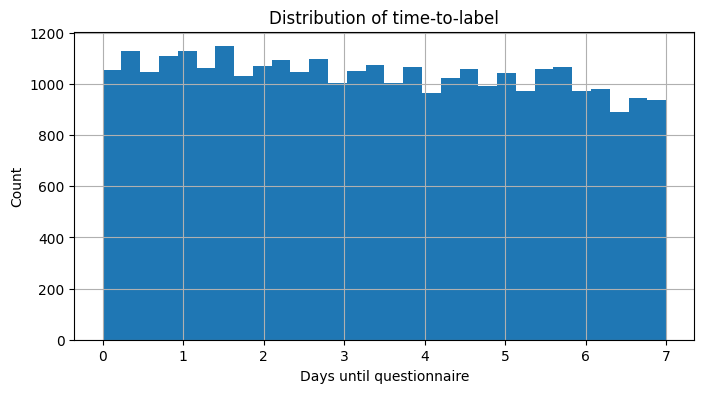

In [32]:
print("Time-to-label days summary:")
print(merged["time_to_label_days"].describe())

plt.figure(figsize=(8, 4))
merged["time_to_label_days"].hist(bins=30)
plt.xlabel("Days until questionnaire")
plt.ylabel("Count")
plt.title("Distribution of time-to-label")
plt.show()

In [33]:
labeled_parquet_path = DATA_PROCESSED / "baseline_smartwatch_features_labeled.parquet"
labeled_csv_path = DATA_PROCESSED / "baseline_smartwatch_features_labeled.csv"
summary_csv_path = OUTPUT_TABLES / "label_distribution_summary.csv"

merged.to_parquet(labeled_parquet_path, index=False)
merged.to_csv(labeled_csv_path, index=False)

label_summary = (
    merged["target_binary"]
    .value_counts(dropna=False)
    .rename_axis("label")
    .reset_index(name="count")
)

label_summary["pct"] = label_summary["count"] / label_summary["count"].sum() * 100
label_summary.to_csv(summary_csv_path, index=False)

print("Saved:")
print(labeled_parquet_path)
print(labeled_csv_path)
print(summary_csv_path)

Saved:
/home/mouradox/Downloads/693-project-baseline/data/processed/baseline_smartwatch_features_labeled.parquet
/home/mouradox/Downloads/693-project-baseline/data/processed/baseline_smartwatch_features_labeled.csv
/home/mouradox/Downloads/693-project-baseline/outputs/tables/label_distribution_summary.csv


In [44]:
print(weekly[[USER_COL, "date", "questionnaire_relative_minute"]].head(15))

    user_key  date  questionnaire_relative_minute
0        113     1                           2880
1        113     7                          11520
2        113    14                          21600
3        113    22                          33120
4        113    28                          41760
5        113    35                          51840
6        113    42                          61920
7        113    49                          72000
8        113    57                          83520
9        113    63                          92160
10       113    70                         102240
11       113    77                         112320
12       113    84                         122400
13       113    91                         132480
14       113    98                         142560
